In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

In [2]:
df_train = pd.read_csv("/kaggle/input/playground-series-s5e5/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s5e5/test.csv")

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [4]:
df_train.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [5]:
df_test.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5


In [6]:
# missing values
print("Train Set Missing Values")
print(df_train.isna().sum())
print( )
print("Test Set Missing Values")
print(df_test.isna().sum())

Train Set Missing Values
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Test Set Missing Values
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64


wowow no missing values!

In [7]:
# summary statistics
print("Train Set Summary Statistics")
print(df_train.describe())
print( )
print("Test Set Summary Statistics")
print(df_test.describe())

Train Set Summary Statistics
                  id            Age         Height         Weight  \
count  750000.000000  750000.000000  750000.000000  750000.000000   
mean   374999.500000      41.420404     174.697685      75.145668   
std    216506.495284      15.175049      12.824496      13.982704   
min         0.000000      20.000000     126.000000      36.000000   
25%    187499.750000      28.000000     164.000000      63.000000   
50%    374999.500000      40.000000     174.000000      74.000000   
75%    562499.250000      52.000000     185.000000      87.000000   
max    749999.000000      79.000000     222.000000     132.000000   

            Duration     Heart_Rate      Body_Temp       Calories  
count  750000.000000  750000.000000  750000.000000  750000.000000  
mean       15.421015      95.483995      40.036253      88.282781  
std         8.354095       9.449845       0.779875      62.395349  
min         1.000000      67.000000      37.100000       1.000000  
25%      

The summary statistics for both datasets look roughly similar, no need to account for differences in samples

In [8]:
len(df_train)

750000

In [9]:
df_all = pd.concat([df_train, df_test]).reset_index(drop=True)

train_indices = len(df_train) - 1

df_all.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,750000.000000
mean,499999.500000,41.428419,174.704670,75.146179,15.419618,95.482767,40.036213,88.282781
std,288675.278933,15.175728,12.823881,13.981899,8.352851,9.449920,0.779518,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,249999.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,499999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,749999.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,999999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


# EDA

## Numeric Features

In [10]:
df_train.drop(columns=['id'], inplace=True)
num_vars = df_train.select_dtypes(include=['int64','float64']).columns
cat_vars = ['Sex']

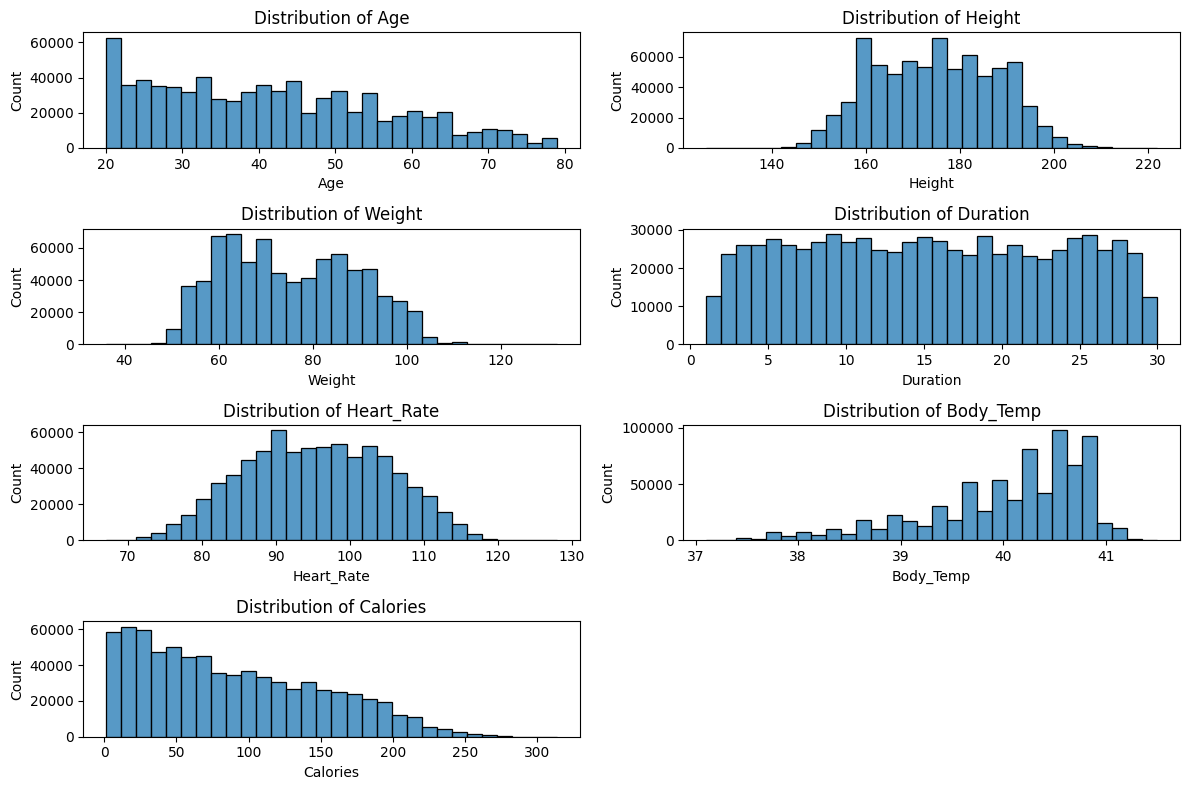

In [11]:
# distribution of Numeric Features
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(num_vars):
    sns.histplot(df_train[feature], ax=axes[i], bins=min(30, df_train[feature].nunique()))
    axes[i].set_title(f"Distribution of {feature}")

axes[7].remove()
plt.tight_layout()
plt.show()

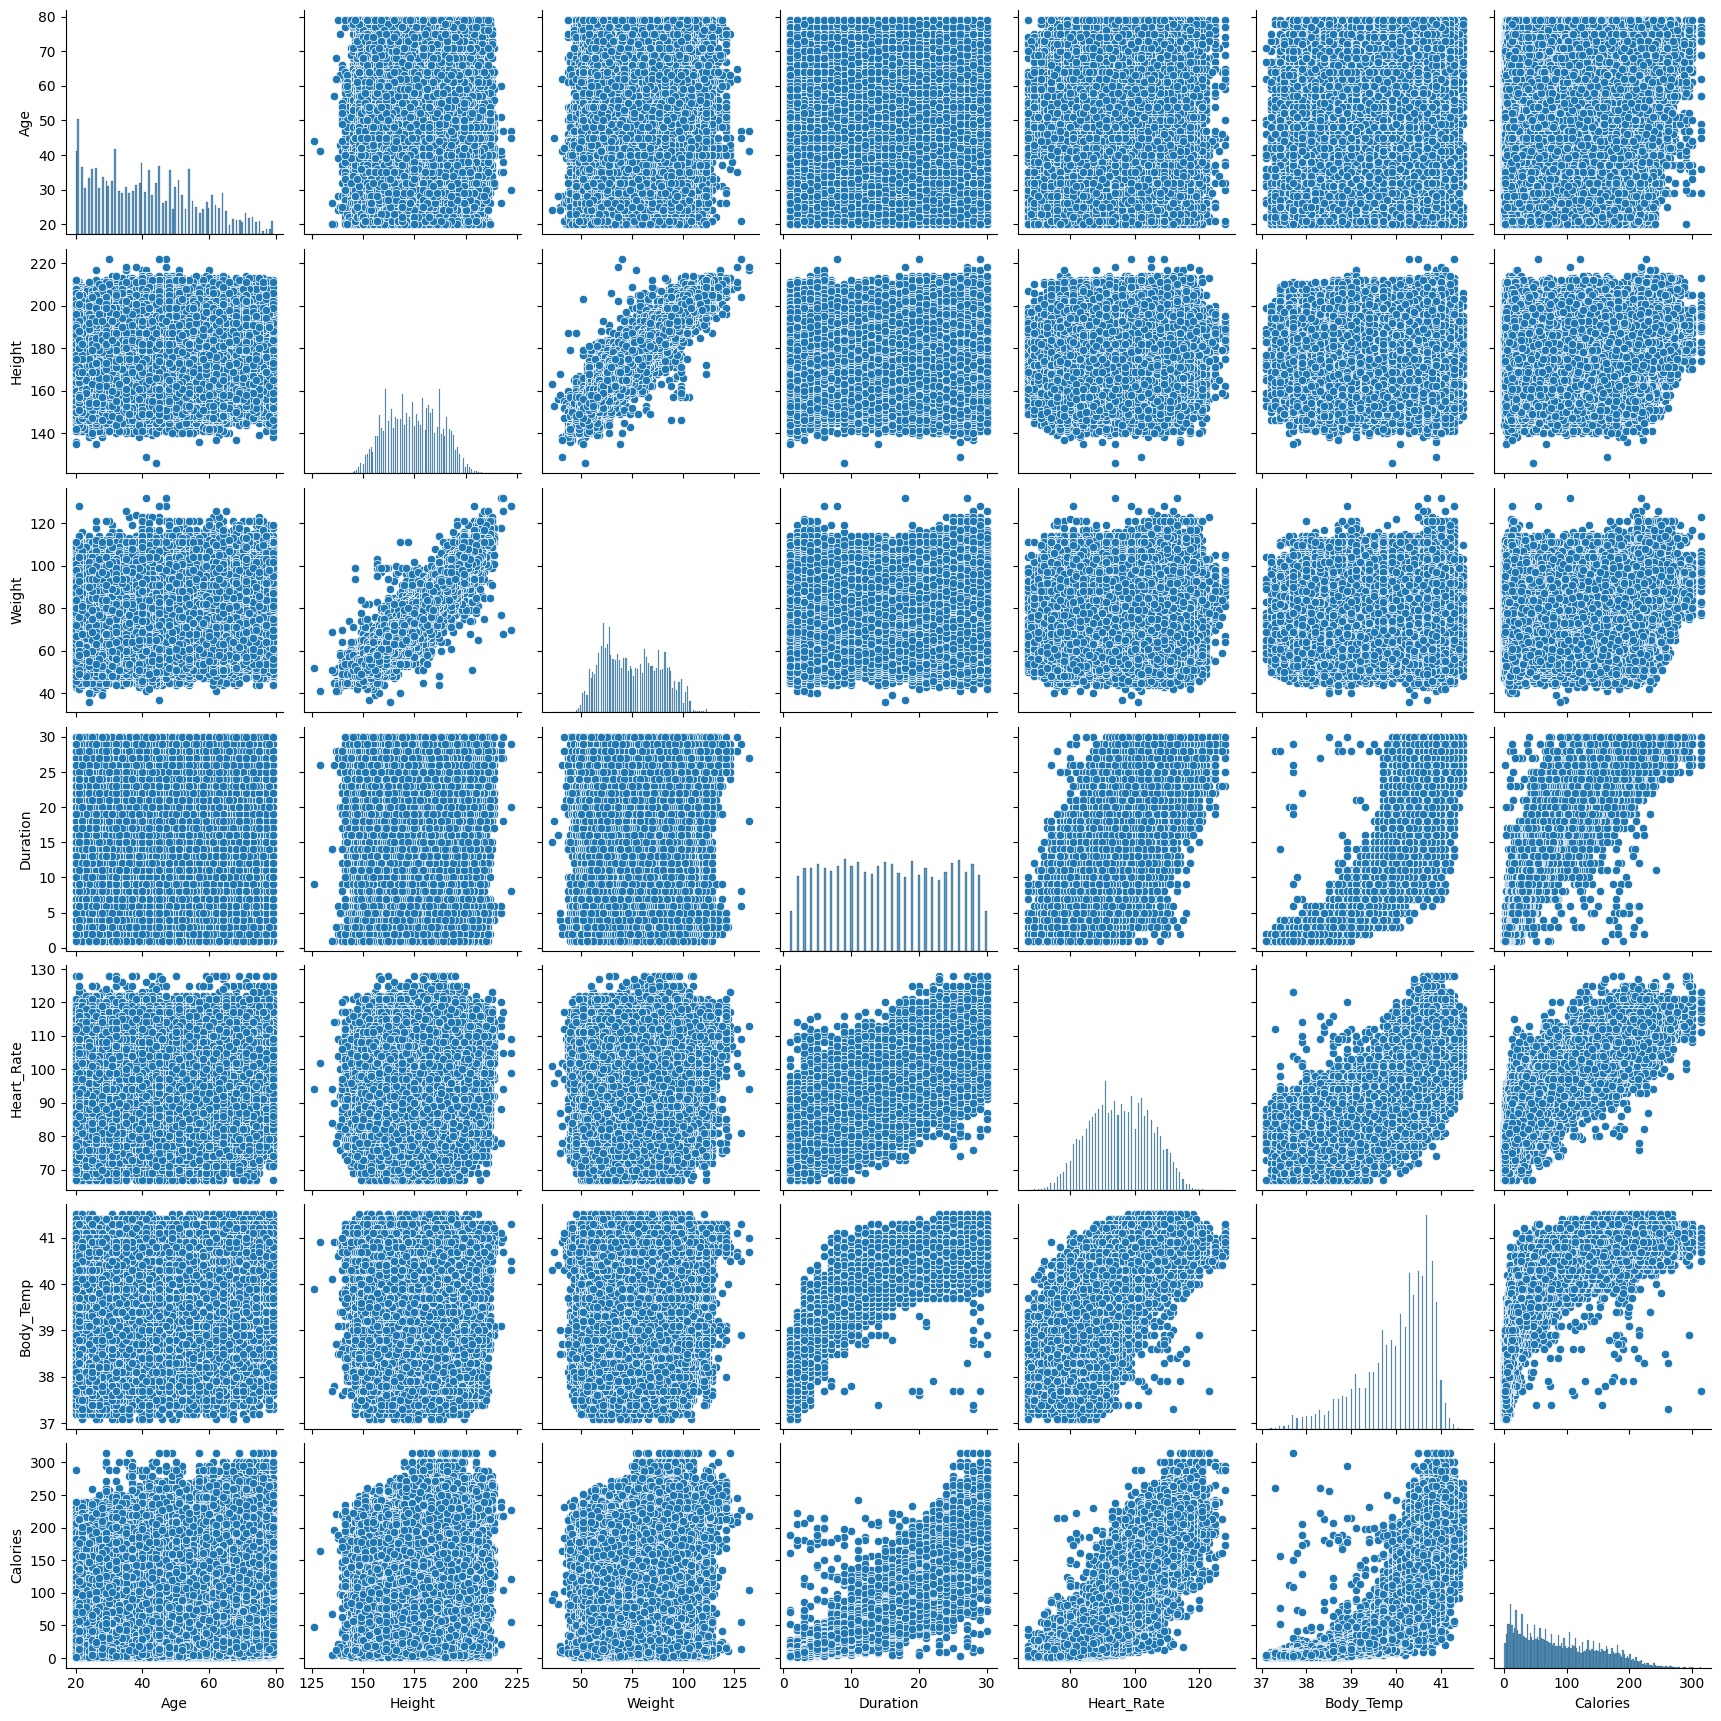

In [12]:
# Scatterplots between features
sns.pairplot(df_train[num_vars])
plt.show()

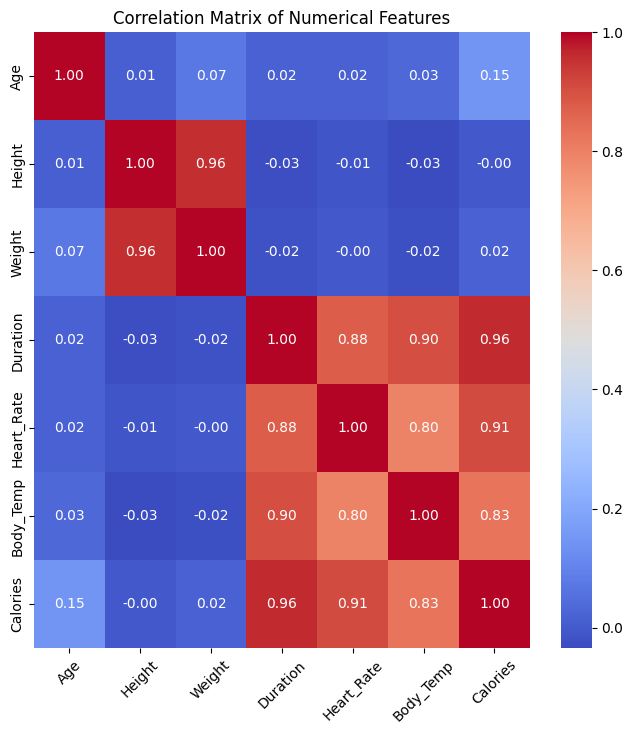

In [13]:
# correlation Matrix
corr_matrix = df_train[num_vars].corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.xticks(rotation=45)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Findings from Analysis of Numerical Features
#### Relationships and Nature of Variables
- There are quite a few significantly correlated features. However, most of the relationship occurs in a non-linear manner as seen in the scatterplot.
- The outcome variable calories is highly right skewed, it might be worth applying a log transformation to make it normally distributed. This should also help with making the relationships between many of the variables and the outcome to be linear.
#### Things to Try
- Applying log transformations to calories
- Looking into interaction terms for investigating how variables such as age, height, and weight, may be indirectly correlated with the outcome variable calories

## Categorical Feature

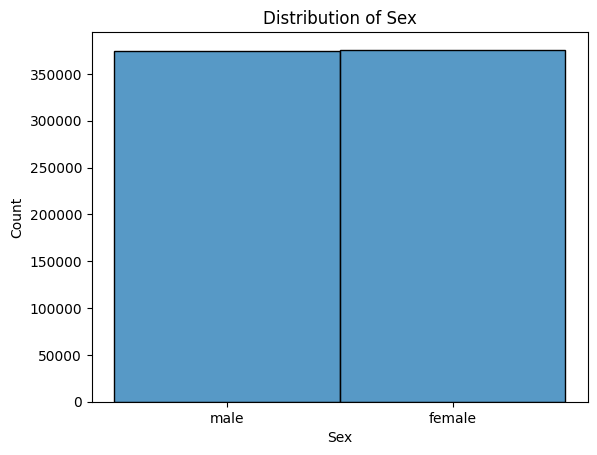

In [14]:
# distribution
sns.histplot(df_train['Sex'])
plt.title("Distribution of Sex")
plt.show()

- There is a even amount of males and females in the sample, not much to worry about here

## Numeric and Categorical Features

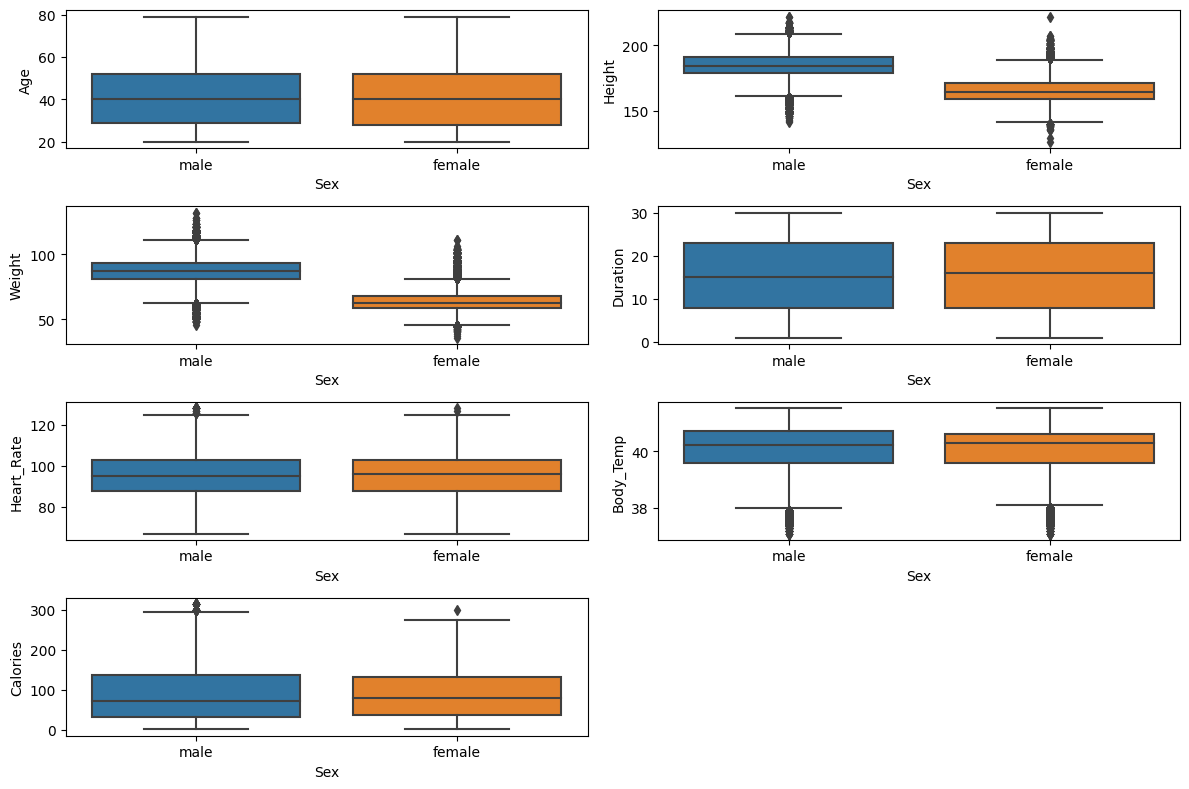

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(num_vars):
    sns.boxplot(x=df_train['Sex'], y=df_train[feature], ax=axes[i])
    plt.title(f"Relationship Between {feature} and Sex")

axes[7].remove()
plt.tight_layout()
plt.show()

### Findings from Analysis of Numerical and Cateogircal Features
- There does not appear to be a significant difference in the mean calories burn for males and females but it is possible that there might be some indirect relationship through the variables of weight and height

# Model

## Linear Regression Baseline

In [16]:
SEED = 7

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split

In [18]:
X = df_train.drop(columns=['Calories'])
X = pd.get_dummies(X, columns=cat_vars, drop_first=True)
y = df_train['Calories']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=SEED)

In [19]:
X.head()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Sex_male
0,36,189.0,82.0,26.0,101.0,41.0,True
1,64,163.0,60.0,8.0,85.0,39.7,False
2,51,161.0,64.0,7.0,84.0,39.8,False
3,20,192.0,90.0,25.0,105.0,40.7,True
4,38,166.0,61.0,25.0,102.0,40.6,False


In [20]:
lr_baseline = LinearRegression()
lr_baseline.fit(X_train, y_train)

LinearRegression()

In [21]:
coefs = {}
for i in range(len(X.columns)):
    coefs[X.columns[i]] = lr_baseline.coef_[i]
coefs['intercept'] = lr_baseline.intercept_
print(coefs)

{'Age': 0.5320032550201722, 'Height': -0.144767564202407, 'Weight': 0.265777410439889, 'Duration': 6.758118949934146, 'Heart_Rate': 1.947901490526429, 'Body_Temp': -18.161329484969627, 'Sex_male': -1.650527948212409, 'intercept': 509.28518763151766}


In [22]:
y_val_pred = lr_baseline.predict(X_val)
y_val_pred = np.maximum(y_val_pred, 0)
score = mean_squared_log_error(y_val_pred, y_val)
print(f"Baseline Validation Score: {score}") # wowie this sucks!

Baseline Validation Score: 0.3208536103471809


# Submission

In [23]:
lr_baseline.fit(X, y)

X_test = df_test.drop(columns=['id'])
X_test = pd.get_dummies(X_test, columns=['Sex'], drop_first=True)
y_test_pred = lr_baseline.predict(X_test)

submission = pd.read_csv("/kaggle/input/playground-series-s5e5/sample_submission.csv")
submission['Calories'] = y_test_pred
submission.to_csv('submission.csv', index=False)
submission.head()

,id,Calories
0,750000,21.420540
1,750001,114.687937
2,750002,93.228689
3,750003,130.798574
4,750004,73.693147


#